In [5]:
import pathlib

import reskit as rk
import numpy as np
import pandas as pd


In [6]:
# Create Placements DataFrame with turbine locations and specifications

geokit_df = pd.read_csv(pathlib.Path.cwd().joinpath("offshore_wind_turbine_depths.csv"))

geokit_df.rename(columns={"Latitude": "lat", "Longitude": "lon"}, inplace=True)
number_of_placements=geokit_df.shape[0]

depth_series = depth_series = geokit_df.loc[:, "depth"]

# Nabenhöhe
hub_height_series = pd.Series(data=[140] * number_of_placements,name="hub_height") 
# Capacity in kW
capacity_series = pd.Series(data=[9500] * number_of_placements, name="capacity")
# Rotordurchmesser in m
rotor_diameter_series = pd.Series(data=[164] * number_of_placements, name="rotor_diam")
# Power Curve
power_curve_series = pd.Series(data=["V164-9500"] * number_of_placements, name="powerCurve")

total_height_series = depth_series + hub_height_series

placements_df = pd.concat(
    [
        geokit_df.loc[:, "lat"],
        geokit_df.loc[:, "lon"],
        hub_height_series,
        capacity_series,
        rotor_diameter_series,
        power_curve_series,
    ],axis=1
)
print(placements_df.head(5))
# placements = pd.DataFrame(
#     {
#         "lon": [5.985195, 5.994685, 6.004750],
#         "lat": [50.797254, 50.794208, 50.784432],
#         "hub_height": [120, 120, 82],
#         "capacity": [4000, 4000, 4000],
#         "rotor_diam": [130, 150, 136],
#         "powerCurve": [np.nan, np.nan, "V117-3300"],
#     }
# )
# placements



         lat       lon  hub_height  capacity  rotor_diam powerCurve
0  51.590921  2.890734         140      9500         164  V164-9500
1  51.595143  2.899807         140      9500         164  V164-9500
2  51.586339  2.897291         140      9500         164  V164-9500
3  51.581578  2.904927         140      9500         164  V164-9500
4  51.568373  2.929721         140      9500         164  V164-9500


In [ ]:

weather_year = 2018

workflow_args = {
    "placements": placements_df,
    "era5_path": f"/benchtop/shared_data/weather_data/processed_weather_data/ERA5_global_processed_V2022.02/4/<X-TILE>/<Y-TILE>/{weather_year}/reanalysis-era5-single-levels.z4.x<X-TILE>.y<Y-TILE>.y{weather_year}.*.nc",
    "gwa_100m_path": "/benchtop/internal/home/c-winkler/Research/01_Dissertation/03_RESkit/01_preprocessing/01_expand_GWA_to_EEZ/01_avg_annual_windspeed_100m_GWA_ERA5_interpolated.tif",
    "max_batch_size": 20000,
    "height_scaling_data": {
        10: "/fast/central/shared_data/Global_Wind_Atlas/GWA_4.0/wind_speed_cog_10m.tif",
        50: "/fast/central/shared_data/Global_Wind_Atlas/GWA_4.0/wind_speed_cog_50m.tif",
        100: "/fast/central/shared_data/Global_Wind_Atlas/GWA_4.0/wind_speed_cog_100m.tif",
        150: "/fast/central/shared_data/Global_Wind_Atlas/GWA_4.0/wind_speed_cog_150m.tif",
        200: "/fast/central/shared_data/Global_Wind_Atlas/GWA_4.0/wind_speed_cog_200m.tif",
    },
}


out = rk.execute_workflow_iteratively(
    workflow=rk.wind.wind_era5_PenaSanchezDunkelWinklerEtAl2025,
    weather_path_varname="era5_path",
    zoom=4,
    **workflow_args,
)

# extract the mean cfs for these 2 turbines
cfs = out.capacity_factor.values.mean(axis=0)



2026-01-26 15:44:49.680576 Now processing tile 1/4 with 13533 locations: /benchtop/shared_data/weather_data/processed_weather_data/ERA5_global_processed_V2022.02/4/8/5/2018/reanalysis-era5-single-levels.z4.x8.y5.y2018.*.nc
2026-01-26 15:48:58.599297 Now extracting correction factors for a total of 13533 placements from /fast/home/j-belina/RESKit/reskit/wind/core/data/cf_correction_factors_PSDW2025.tif:
2026-01-26 15:49:03.906184 Based on max_batch_size=13533, the total of 13533 placements were split into 1 sub batches. Proceeding with batch 1/1 (id=0) with 13533 placements.
2026-01-26 15:49:10.668925 Maximum rel. deviation after initial simulation is 0.2885, Number/share of placements with deviation > tolerance (0.01): 13533/13533. More iterations required.
2026-01-26 15:49:18.204354 Maximum rel. deviation after 1 additional iteration(s) is 0.1062, Number/share of placements with deviation > tolerance (0.01): 13533/13533. More iterations required.
2026-01-26 15:49:26.654277 Maximum rel

In [ ]:
mean_data_frame=out["capacity_factor"].mean(dim="time")
print(mean_data_frame)
print(mean_data_frame.min())
print(mean_data_frame.max())


<xarray.DataArray 'capacity_factor' (location: 19605)> Size: 157kB
array([0.37874203, 0.37872078, 0.3785476 , ..., 0.40408756, 0.40398956,
       0.40377667])
Coordinates:
  * location  (location) int64 157kB 0 1 2 3 4 ... 19442 19443 19444 19445 19446
<xarray.DataArray 'capacity_factor' ()> Size: 8B
array(0.29513326)
<xarray.DataArray 'capacity_factor' ()> Size: 8B
array(0.45272084)


<Axes: >

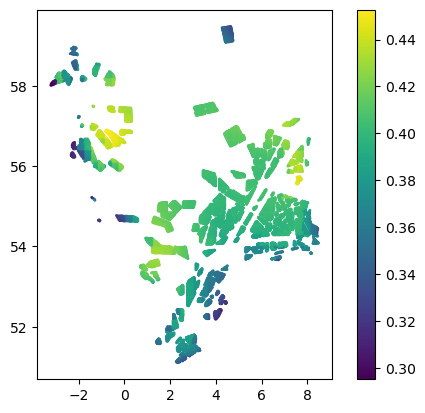

In [23]:
mean_data_frame = out.mean(dim="time").to_dataframe()
import geopandas as gpd
gdf = gpd.GeoDataFrame(
    mean_data_frame,
    geometry=gpd.points_from_xy(
        mean_data_frame["lon"], mean_data_frame["lat"]
    ),
    crs="EPSG:4326",
)
gdf.plot(column="capacity_factor", cmap="viridis",legend=True, markersize=1)


In [26]:
from reskit.util.economic.lcoe import levelized_cost_of_electricity_simplified

mean_production=mean_data_frame.loc[:, "capacity_factor"]*mean_data_frame.loc[:, "capacity"]*8760  # in kWh

mean_data_frame.loc[:, "capex"]=1000*mean_data_frame.loc[:, "capacity"]  # in USD

lcoe_df=levelized_cost_of_electricity_simplified(capex=mean_data_frame.loc[:, "capex"], mean_production=mean_production)

lcoe_df_ct=lcoe_df * 100

print(lcoe_df_ct.min())
print(lcoe_df_ct.max())
print(lcoe_df_ct.mean())

3.0725489364369545
4.713148654351784
3.5290498038999956


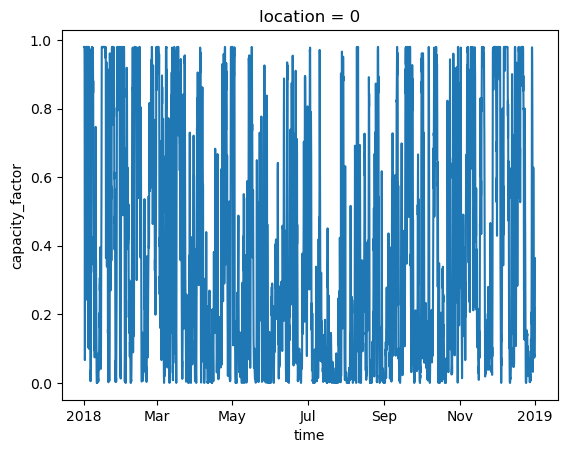

In [ ]:
out.isel(location=0)["capacity_factor"].plot()
# out